# 01 — Exploratory Data Analysis: Wisesight Sentiment

**Task:** Multi-class sentiment (`positive` / `neutral` / `negative` / `question`) in Thai from Wisesight Sentiment Corpus

**Goals of this notebook:**
1. Verify the schema / real label mapping from the dataset (no hardcoding).
2. Examine **class imbalance** → use this in interviews to explain why we use macro-F1 + weighted loss.
3. Examine text length distribution → use this to determine `MAX_LEN`.
4. Look at actual examples + edge cases (code-mixing, emojis, short/long texts).

> All figures are saved to `reports/figures/` for use in the README.
>
> Running on Colab: `!git clone <repo>` → `%cd thai-sentiment` → `!pip install -r requirements.txt`, then run this notebook.

In [1]:
# --- Enable importing config / src whether running from notebooks/ or repo root (or on Colab after clone) ---
import sys
from pathlib import Path

_cwd = Path.cwd()
REPO = next((p for p in (_cwd, _cwd.parent) if (p / "config.py").exists()), _cwd)
sys.path.insert(0, str(REPO))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import config
from src.data import load_splits, get_label_info
set_seed(config.SEED)
sns.set_theme(style="whitegrid")

LABELS = info["names"]

print("Splits     :", {k: v.num_rows for k, v in ds.items()})
print("Text column:", config.TEXT_COL, "| Label column:", config.LABEL_COL)
print("Columns    :", ds["train"].column_names)
print("Labels     :", info["id2label"])
print("Label feat :", ds["train"].features[config.LABEL_COL])


2026-07-17 02:13:11,755 | INFO | HTTP Request: HEAD https://huggingface.co/datasets/pythainlp/wisesight_sentiment/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-07-17 02:13:11,772 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/pythainlp/wisesight_sentiment/85a79ed833429457227182c9f61a83e9127dfa2e/README.md "HTTP/1.1 200 OK"
2026-07-17 02:13:12,058 | INFO | HTTP Request: HEAD https://huggingface.co/datasets/pythainlp/wisesight_sentiment/resolve/85a79ed833429457227182c9f61a83e9127dfa2e/wisesight_sentiment.py "HTTP/1.1 404 Not Found"
2026-07-17 02:13:12,850 | INFO | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/pythainlp/wisesight_sentiment/pythainlp/wisesight_sentiment.py "HTTP/1.1 404 Not Found"
2026-07-17 02:13:13,245 | INFO | HTTP Request: GET https://huggingface.co/api/datasets/pythainlp/wisesight_sentiment/revision/85a79ed833429457227182c9f61a83e9127dfa2e "HTTP/1.1 200 OK"
2026-07-17 02:13:13,533 |

cleaning text:   0%|          | 0/21628 [00:00<?, ? examples/s]

cleaning text:   0%|          | 0/2404 [00:00<?, ? examples/s]

cleaning text:   0%|          | 0/2671 [00:00<?, ? examples/s]

drop empties:   0%|          | 0/21628 [00:00<?, ? examples/s]

...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

2026-07-17 02:13:22,162 | INFO | Saved validation split (2404 rows) -> C:\Users\ASUS\Data_Science\Projects\08_Thai_Sentiment\thai-sentiment\data\validation.parquet


Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

2026-07-17 02:13:22,264 | INFO | Saved test split (2671 rows) -> C:\Users\ASUS\Data_Science\Projects\08_Thai_Sentiment\thai-sentiment\data\test.parquet


Splits     : {'train': 21628, 'validation': 2404, 'test': 2671}
Text column: texts | Label column: category
Columns    : ['texts', 'category']
Labels     : {0: 'pos', 1: 'neu', 2: 'neg', 3: 'q'}
Label feat : ClassLabel(names=['pos', 'neu', 'neg', 'q'])


## 1. Class distribution — Highly imbalanced data

`neutral` is the majority class and `question` is the minority class (only 476 examples) →
This is the reason we choose **macro-F1** as the primary metric (instead of accuracy, which is biased towards the majority class) and use **weighted loss** during fine-tuning.

            count  pct_%
label_name              
pos          3866   17.9
neu         11795   54.5
neg          5491   25.4
q             476    2.2

Imbalance ratio (max/min class): 24.8x
saved -> C:\Users\ASUS\Data_Science\Projects\08_Thai_Sentiment\thai-sentiment\reports\figures\class_distribution.png


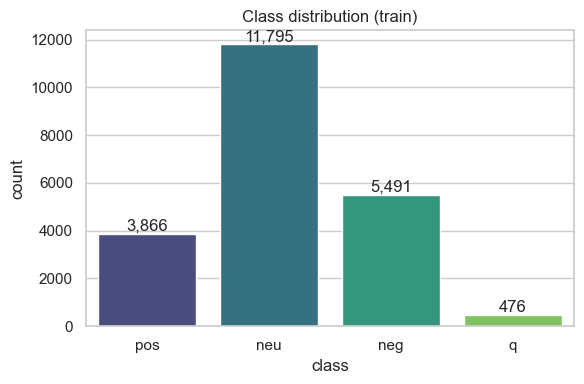

In [2]:
train_df = ds["train"].to_pandas()
train_df["label_name"] = train_df[config.LABEL_COL].map(info["id2label"])

counts = train_df["label_name"].value_counts().reindex(LABELS)
ratio = (counts / counts.sum() * 100).round(1)
print(pd.DataFrame({"count": counts, "pct_%": ratio}))
print(f"\nImbalance ratio (max/min class): {counts.max() / counts.min():.1f}x")

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=list(counts.index), y=list(counts.values),
            hue=list(counts.index), legend=False, palette="viridis", ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set_title("Class distribution (train)")
ax.set_xlabel("class")
ax.set_ylabel("count")
plt.tight_layout()
out = config.FIGURES_DIR / "class_distribution.png"
fig.savefig(out, dpi=150)
print("saved ->", out)
plt.show()


## 2. Text length → Choosing `MAX_LEN`

Looking from 2 perspectives: (A) Number of **characters** and (B) Number of **subword tokens** after tokenizing with WangchanBERTa.
The most important factor for setting `MAX_LEN` is (B) because the model processes text as subwords, not characters.

2026-07-17 02:13:27,295 | INFO | HTTP Request: HEAD https://huggingface.co/airesearch/wangchanberta-base-att-spm-uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-17 02:13:27,625 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/airesearch/wangchanberta-base-att-spm-uncased/b81d38df6b4755dbedec0bfea863c9956cbb963e/config.json "HTTP/1.1 200 OK"
2026-07-17 02:13:27,962 | INFO | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/airesearch/wangchanberta-base-att-spm-uncased/b81d38df6b4755dbedec0bfea863c9956cbb963e/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

c:\Users\ASUS\miniconda3\envs\dl\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--airesearch--wangchanberta-base-att-spm-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
2026-07-17 02:13:28,301 | INFO | HTTP Request: HEAD https://huggingface.co/airesearch/wangc

       n_chars  n_tokens
count  21628.0   21628.0
mean      89.7      31.0
std      149.2      49.4
min        1.0       3.0
50%       39.0      15.0
90%      222.0      71.0
95%      329.0     109.0
99%      742.2     250.0
max     1997.0     856.0

สัดส่วนข้อความที่ <= MAX_LEN (256 tokens): 99.07%
saved -> C:\Users\ASUS\Data_Science\Projects\08_Thai_Sentiment\thai-sentiment\reports\figures\text_length.png


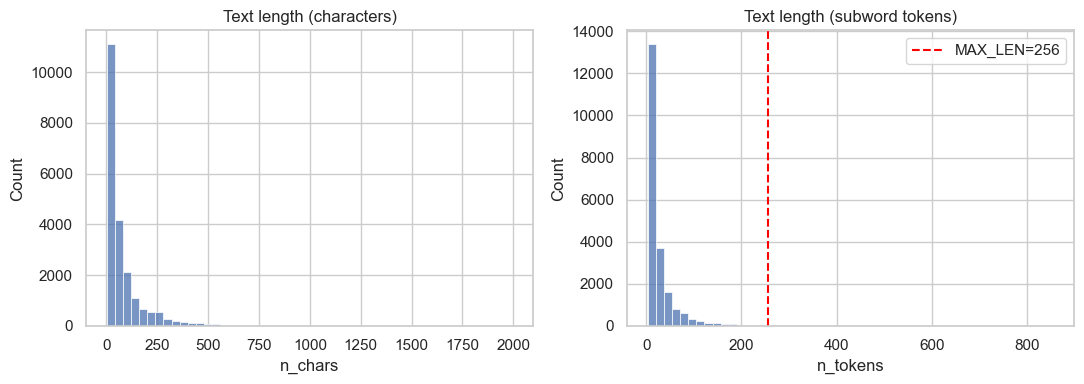

In [3]:
from transformers import AutoTokenizer

train_df["n_chars"] = train_df[config.TEXT_COL].str.len()
# Count actual subword tokens (not yet truncated to see true distribution)
# นับ subword tokens จริง (ยังไม่ truncate เพื่อดู distribution ที่แท้จริง)
train_df["n_tokens"] = [len(tok.encode(t, add_special_tokens=True)) for t in train_df[config.TEXT_COL]]
print(f"\nProportion of texts <= MAX_LEN ({config.MAX_LEN} tokens): {pct_within:.2f}%")
print(train_df[["n_chars", "n_tokens"]].describe(percentiles=[.5, .9, .95, .99]).round(1))
pct_within = (train_df["n_tokens"] <= config.MAX_LEN).mean() * 100
print(f"\nสัดส่วนข้อความที่ <= MAX_LEN ({config.MAX_LEN} tokens): {pct_within:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train_df["n_chars"], bins=50, ax=axes[0])
axes[0].set_title("Text length (characters)")
sns.histplot(train_df["n_tokens"], bins=50, ax=axes[1])
axes[1].axvline(config.MAX_LEN, color="red", ls="--", label=f"MAX_LEN={config.MAX_LEN}")
axes[1].set_title("Text length (subword tokens)")
axes[1].legend()
plt.tight_layout()
out = config.FIGURES_DIR / "text_length.png"
fig.savefig(out, dpi=150)
print("saved ->", out)
plt.show()


## 3. Actual examples per class + edge cases

Observe the characteristics of Thai social media texts: **code-mixing** (mixing with English), **emojis**, **misspellings/repeated words** (e.g., อร่อยมากกก), and **sarcasm** — these are the main sources of errors that we will analyze in Phase 6.

In [4]:
# 4 actual examples per class — looking for code-mixing / emoji / misspelling / sarcasm
for idx, name in info["id2label"].items():
    print(f"\n===== {name}  (label={idx}) =====")
    samples = train_df.loc[train_df[config.LABEL_COL] == idx, config.TEXT_COL].head(4).tolist()
    for s in samples:
        print("  •", s[:200])



===== pos  (label=0) =====
  • 😍😍
  • พอๆกับ, Juke : รถอะไรวะ ทรงประหลาด CHR : สวย ล้ำ คุ้ม
  • เหมาะกะมึงที่สัสคะ เอ้ย สุด
  • สู้ๆนะคร้าฟผมๆๆๆๆๆ

===== neu  (label=1) =====
  • ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกรานต์เลย รอขับอยู่นาจา กระทัดรัด เหมาะกับสาวๆขับรถคนเดียวแบบเรา ราคาสบายกระเป๋า ประหยัดน้ำมัน วิ่งไกลแค่ไหนหายห่วงค่ะ
  • เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึก #ช้างเอฟเอคัพ นัดชิงชนะเลิศ
  • บัตรสมาชิกลดได้อีกไหมคับ
  • สนใจ new mazda2ครับ

===== neg  (label=2) =====
  • 张丽霞 อ้อออ ผ้าอนามัยแบบสอดอ่ะนะ กุกลัวมาก 5555555
  • ไม่ขอบสีโทนนี้แล้ว ไปชอบโทน tarte bloom หยั่กดั้ยมากกก
  • ไปจับบุหรี่ไฟฟ้าในคลิป ตำรวจเป็น10คนได้ละมั่ง ผู้หญิงคนเดียว ตลกดี ของกลางบุหรี่ไฟฟ้า เป็นอันตรายต่อประเทศชาติอย่างรุนแรง อาจทำให้น้ำท่วม พายุได้
  • เออ ข่าวบาบีก้อนอะที่เค้าบอกกันว่าถ้าสุกก็กินได้ คือพยาธิตายยังไงอะ แบบสลายหายไปเลยหรือเป็นซากอะ ถ้าเป็นซากก็กินไม่ไหวนะ 😂

===== q  (label=3) =====
  • ทำไมรถฟอร์ดไม่ใส่ ครีบฉลาม Shark Fin มาให้ด้วยนะ
  • อยู่เมืองชลบุรีแป้งเจ้าน

## EDA Summary (Useful for interviews)

- **Highly Imbalanced**: `question` is the smallest class (476 examples, 24.8x imbalance ratio) → Expect lowest F1 score → Hence, we use **macro-F1** as the primary metric and **weighted loss** during fine-tuning.
- **Short texts**: Most subword tokens are << 256 → `MAX_LEN=256` covers 99.07% of the data.
- **Thai has no word boundaries** → baseline requires `pythainlp.word_tokenize`; transformer uses SentencePiece (so we do **not** segment words before feeding the model).
- **Edge cases** (code-mixing / emoji / sarcasm) are areas where the model often fails → We will analyze these in `src/error_analysis.py` (Phase 6).

Output image files: `reports/figures/class_distribution.png`, `reports/figures/text_length.png`